In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pprint

import hydra
from omegaconf import OmegaConf
import polars as pl
import numpy as np
import torch
from einops import reduce
import lightning.pytorch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=2)

import conf.dataset
from conf import conf
from g_led import main_sequential, datasets, models, utils

In [3]:
engine = conf.get_engine()
conf.orm.create_all(engine)
db = conf.sa.orm.Session(engine, expire_on_commit=False)
db.begin()

In [4]:
runs = pl.DataFrame(
    orient='row',
    schema=[
        'alt_id', 'label',
    ],
    data=[
        ['rj700zkc', 'model'],
    ]
)
runs

alt_id,label
str,str
"""rj700zkc""","""model"""


In [7]:
cfgs = db.execute(conf.sa.select(conf.Conf).where(conf.Conf.alt_id.in_(runs.get_column('alt_id'))))
cfgs = {cfg.alt_id: {'cfg': cfg} for (cfg,) in cfgs}
reference_cfg = next(iter(cfgs.values()))['cfg']
downsampler = datasets.Downsampler(reference_cfg.dataset)
lightning.pytorch.seed_everything(reference_cfg.rng_seed)
with lightning.pytorch.utilities.seed.isolate_rng():
    dataset = datasets.get_dataset(reference_cfg.dataset)
    dataset.prepare_data()
    dataset.setup('predict')

Seed set to 2376999025


In [14]:
for v in cfgs.values():
    cfg = v['cfg']
    model, ckpt_path = models.get_model(cfg)
    train_sequential = main_sequential.TrainSequential.load_from_checkpoint(cfg.run_dir/'last.ckpt', cfg=cfg, downsampler=datasets.Downsampler(cfg.dataset), model=model)
    v['model'] = train_sequential

In [98]:
split = 'val_on_train'
window_idx = 10
window = getattr(dataset, split)[window_idx:window_idx+1]
window_true = downsampler(window)
window_true_flattened = downsampler(window, flatten_solution=True)
print(f'True:     {window_true.shape}')
with torch.no_grad():
    for k, v in cfgs.items():
        window_pred = train_sequential.forecast(window.shape[1] - 1, window_true_flattened[:, :1])
        print(f'{k}: {window_pred.shape}')
        v['window_pred'] = window_pred

True:     torch.Size([1, 450, 2, 32, 32])
rj700zkc: torch.Size([1, 450, 2, 32, 32])


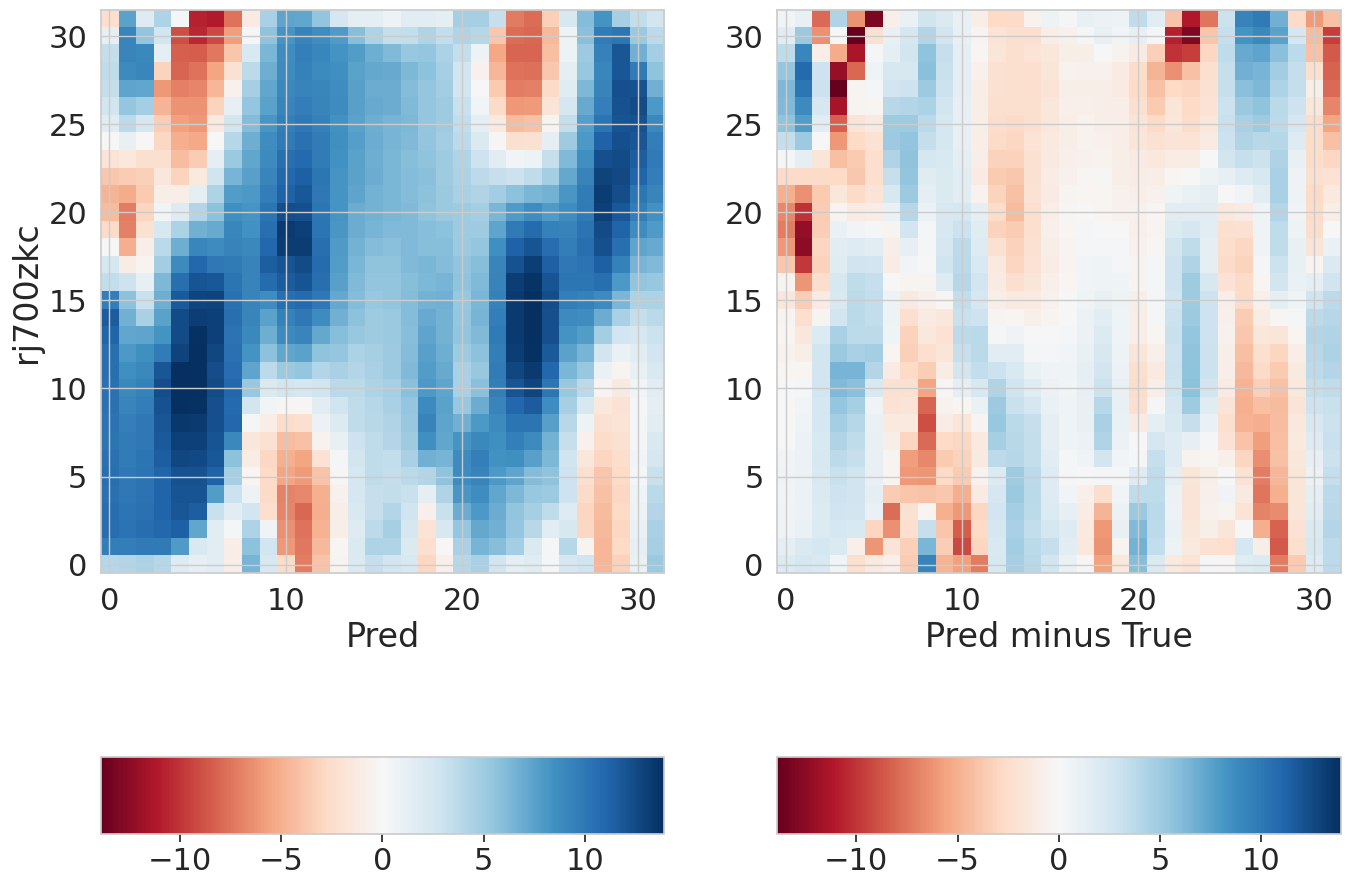

In [99]:
time_step = -1
component = 0
row_order = [*runs.get_column('alt_id')]

data_true = window_true[0, time_step, component]
p = .01
v_abs_max = max(np.quantile(data_true, p), np.quantile(data_true, 1 - p))
plot_cfgs = {
    # 'True': {'window_pred': window_true},
    **cfgs,
}
fig, axs = plt.subplots(figsize=(16, 6 + 6 * len(plot_cfgs)), nrows=len(plot_cfgs) + 1, ncols=2, height_ratios=[*([10] * len(plot_cfgs)), 1])
for axs_row, (model_id, context) in zip(axs, plot_cfgs.items()):
    data = context['window_pred'][0, time_step, component]
    im_out_pred = axs_row[0].imshow(data, cmap='RdBu', origin='lower', vmin=-v_abs_max, vmax=v_abs_max)
    axs_row[0].set_xlabel('Pred')
    axs_row[0].set_ylabel(model_id)
    im_out_err = axs_row[1].imshow(data - data_true, cmap='RdBu', origin='lower', vmin=-v_abs_max, vmax=v_abs_max)
    axs_row[1].set_xlabel('Pred minus True')
fig.colorbar(im_out_pred, cax=axs[-1][0], orientation='horizontal')
fig.colorbar(im_out_err, cax=axs[-1][1], orientation='horizontal')

In [100]:
reference_runs = pl.DataFrame(
    orient='row',
    schema=[
        'alt_id', 'label',
    ],
    data=[
        ['True', 'True'],  # epoch = 20
        # ['LinearInterpolation', 'Linear Interpolation'],
    ]
)

shape: (450, 4)
┌──────────────────┬──────────┬───────────┬───────┐
│ window_time_step ┆ alt_id   ┆ Rel. RMSE ┆ label │
│ ---              ┆ ---      ┆ ---       ┆ ---   │
│ i64              ┆ str      ┆ f32       ┆ str   │
╞══════════════════╪══════════╪═══════════╪═══════╡
│ 0                ┆ rj700zkc ┆ 0.0       ┆ model │
│ 1                ┆ rj700zkc ┆ 0.034621  ┆ model │
│ 2                ┆ rj700zkc ┆ 0.044018  ┆ model │
│ 3                ┆ rj700zkc ┆ 0.049986  ┆ model │
│ 4                ┆ rj700zkc ┆ 0.052346  ┆ model │
│ …                ┆ …        ┆ …         ┆ …     │
│ 445              ┆ rj700zkc ┆ 0.614926  ┆ model │
│ 446              ┆ rj700zkc ┆ 0.620173  ┆ model │
│ 447              ┆ rj700zkc ┆ 0.633557  ┆ model │
│ 448              ┆ rj700zkc ┆ 0.646489  ┆ model │
│ 449              ┆ rj700zkc ┆ 0.653073  ┆ model │
└──────────────────┴──────────┴───────────┴───────┘


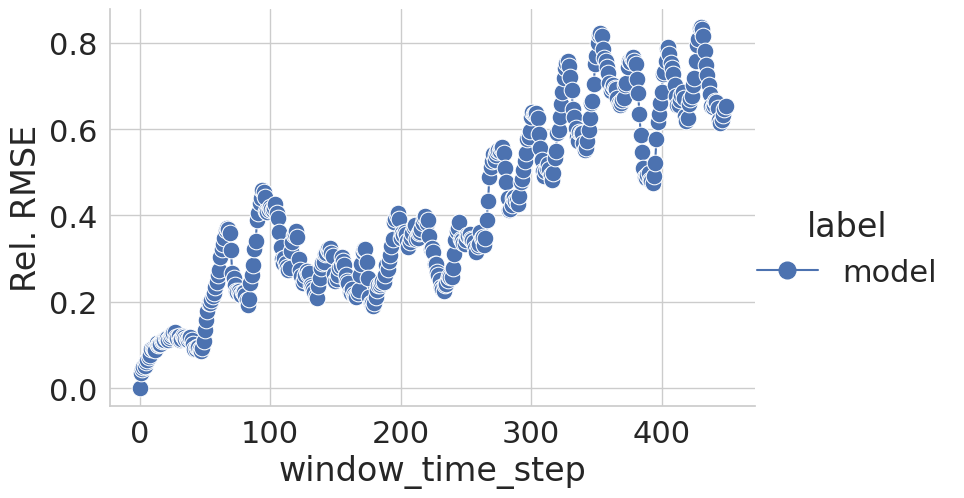

In [101]:
data_true = window_true[0]
rel_rmses = {}
for model_id, context in cfgs.items():
    data = context['window_pred'][0]
    # rmse = reduce(
    #     (data - data_true).abs(),
    #     'batch time component width length -> batch time',
    #     'max'
    # ).sqrt()
    # norm = reduce(
    #     data_true.abs(),
    #     'batch time component width length -> batch time',
    #     'max'
    # ).sqrt()
    # rel_rmses[model_id] = (rmse / norm).mean(0).numpy()
    rmse = reduce(
        (data - data_true).square(),
        'time component width length -> time',
        'mean'
    ).sqrt()
    norm = reduce(
        data_true.square(),
        'time component width length -> time',
        'mean'
    ).sqrt()
    rel_rmses[model_id] = (rmse / norm).numpy()
rel_rmses = pl.DataFrame(rel_rmses).with_columns(window_time_step=pl.int_range(pl.len()))
# print(rel_rmses)
plot_data = (
    rel_rmses
    .unpivot(index='window_time_step', variable_name='alt_id', value_name='Rel. RMSE')
    .join(pl.concat([runs, reference_runs]), on='alt_id', how='left')
)
print(plot_data)
plot_rmse = (
    sns.relplot(
        kind='line',
        data=plot_data,
        x='window_time_step',
        y='Rel. RMSE',
        # hue_order=row_order,
        # style_order=row_order,
        hue='label',
        style='label',
        markers=True,
        markersize=12,
        height=5.5,
        aspect=1.5,
    )
)